In [5]:
import numpy as np
import sympy
from sympy import symbols
from sympy.physics.mechanics import ReferenceFrame, dynamicsymbols
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


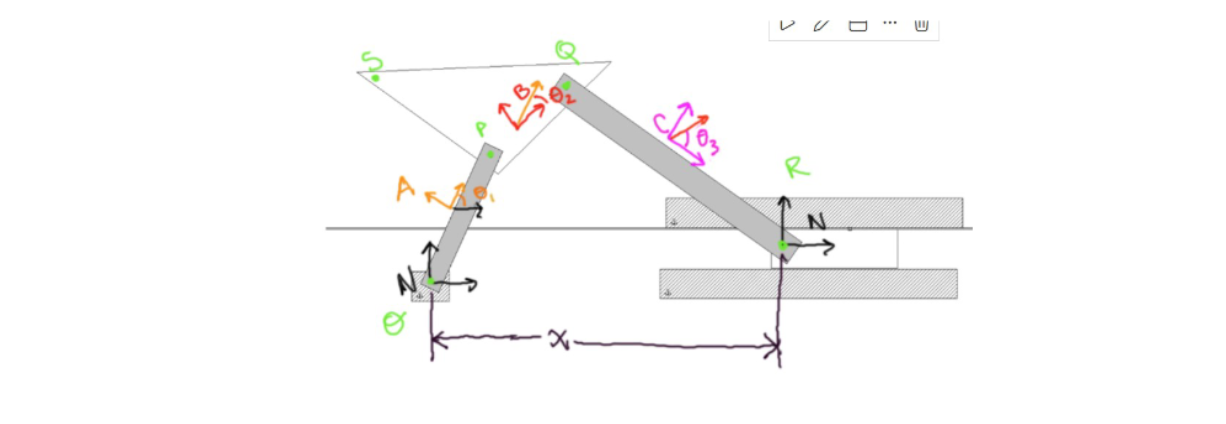
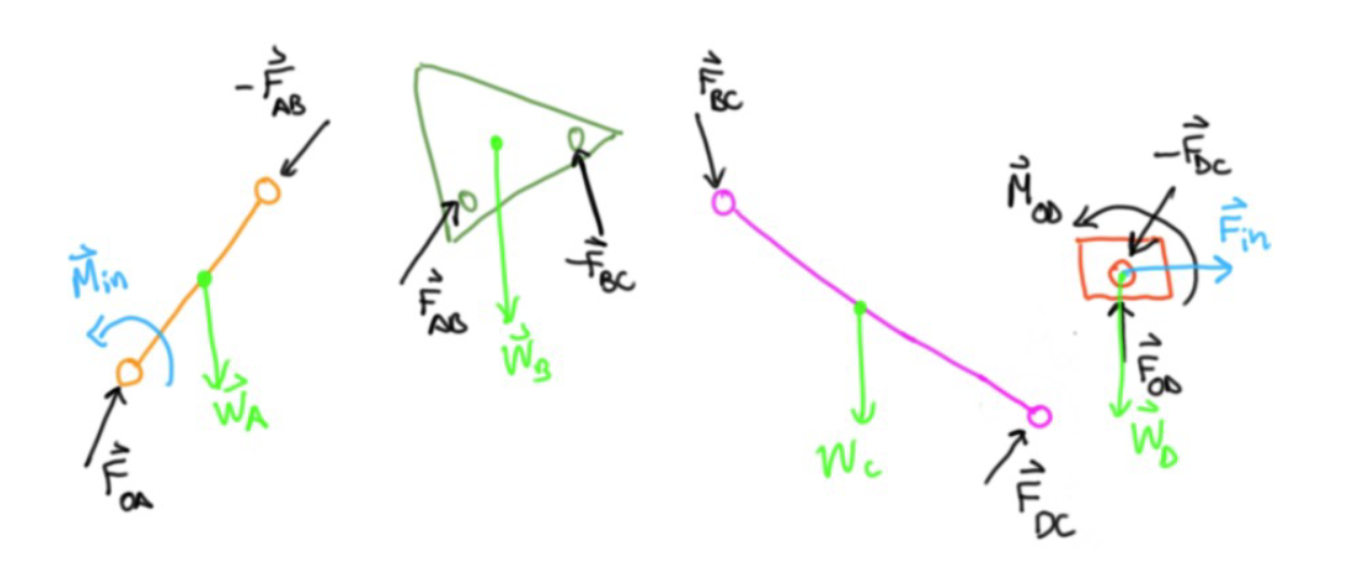

In [6]:
#Symbols 
OP, PQ, PS, QR, OR_y = symbols('OP PQ PS QR OR_y')
IA, IB, IC, mA, mB, mC, mD, t, g = symbols('IA IB IC mA mB mC mD t g')
theta1, theta2, theta3, x = dynamicsymbols('theta1 theta2 theta3 x') #dynamic
#params
params = {OP: 0.2, PQ: 0.15, PS: 0.15, QR: 0.6, OR_y: 0.05,
          mA: 2, mB: 3, mC: 2, mD: 1, g: 9.81}

lcomA, lcomBx, lcomBy, lcomC = OP/2, PQ/3, PS/3, QR/2 #members lenght center of mass
slender_rod_inertia = lambda m, l: m*l**2/12 #lambda func 4 rod inertia
right_triangle_inertia = lambda m, a, b: m*(a**2 + b**2)/18. #lambda func 4 triangle inertia

#Variablles array
dynamicVariables = [theta1, theta2, theta3, x]
dynamicVariablesDot = [v.diff(t) for v in dynamicVariables]
dynamicVariablesDDot = [v.diff(t) for v in dynamicVariablesDot]

params = params | {
    IA: slender_rod_inertia(params[mA], params[OP]),
    IB: right_triangle_inertia(params[mB], params[PQ], params[PS]),
    IC: slender_rod_inertia(params[mC], params[QR])
} #add calculated params (Inertia)

# Define the reference frames
N = ReferenceFrame('N')
A = N.orientnew('A', 'Axis', [theta1, N.z])
B = A.orientnew('B', 'Axis', [-theta2, N.z])
C = B.orientnew('C', 'Axis', [-theta3, N.z])

# Define the vector loop
r1 = OP*A.x
r2 = PQ*B.x
r3 = QR*C.x
r4 = -x*N.x - OR_y*N.y

# Define the vector loop equation
eq = r1 + r2 + r3 + r4
eq_params_subs = eq.subs(params)

eq_fun = sympy.lambdify([theta1, theta2, theta3, x], [eq_params_subs.dot(N.x), eq_params_subs.dot(N.y)]) #lambdify unpack equation

joint_coordinates = {'O': 0*N.x, 'P': r1, 'Q': r1 + r2, 'R': r1 + r2 + r3, 'S': r1 + PS*B.y}

mass_center = {'A': lcomA*A.x,
       'B': joint_coordinates['P'] + lcomBx*B.x + lcomBy*B.y,
       'C': joint_coordinates['Q'] + lcomC*C.x,
       'D': joint_coordinates['R']}

points_fun = {k: sympy.lambdify(dynamicVariables,
                                [v.dot(N.x).subs(params),
                                 v.dot(N.y).subs(params)])
              for k, v in joint_coordinates.items()}

eqV_params = eq_params_subs.diff(t, N)
eqA_params = eq_params_subs.diff(t, N).diff(t, N)

[VV, bv] = sympy.linear_eq_to_matrix(
    [eqV_params.dot(N.x), eqV_params.dot(N.y)],
    [theta2.diff(t), theta3.diff(t)]
)

[AA, ba] = sympy.linear_eq_to_matrix(
    [eqA_params.dot(N.x), eqA_params.dot(N.y)],
    [theta2.diff(t, t), theta3.diff(t, t)]
)

calculateVelocityMatrix = sympy.lambdify(dynamicVariables, VV)
calculate_bias_vector = sympy.lambdify(dynamicVariablesDot + dynamicVariables, bv)
calculateAccelerationMatrix = sympy.lambdify(dynamicVariablesDot + dynamicVariables, AA)
calculate_bias_acceleration = sympy.lambdify(dynamicVariablesDDot + dynamicVariablesDot + dynamicVariables, ba)

#kinemmatics
def FK(q, z0=None):
    fsolve_fun = lambda z: eq_fun(q[0], z[0], z[1], q[1])
    z0 = [np.deg2rad(45), np.deg2rad(90)] if z0 is None else z0 #initil guess
    out = least_squares(fsolve_fun, z0, bounds=([-np.pi, 0], [np.pi, np.pi]))
    return out.x, out

S_fun = points_fun['S']

def IK_error(q, s_star):
    z, _ = FK(q)
    s = np.array(S_fun(q[0], z[0], z[1], q[1]))
    er = 100*np.square(s - s_star).sum()
    return er

def IK(s_star, q0=None):
    q0 = [np.deg2rad(64.43), 0.70] if q0 is None else q0
    res = least_squares(lambda q: IK_error(q, s_star),
                        q0,
                        bounds=([np.deg2rad(10), 0.5], [np.pi, 0.9]))
    return res.x, res

outer_fk, outer = IK(np.array([0.04, 0.3]))

# Define the forces and moments acting on the mechanism
FOAx, FOAy, FABx, FABy, FBCx, FBCy, FDCx, FDCy, FDOy, MOD, Min, Fin = dynamicsymbols(
    'FOAx FOAy FABx FABy FBCx FBCy FDCx FDCy FDOy MOD Min Fin'
)
g, t = symbols('g t')

FOA = FOAx*A.x + FOAy*A.y
FAB = FABx*B.x + FABy*B.y
FBC = FBCx*C.x + FBCy*C.y
FDC = FDCx*C.x + FDCy*C.y
FDO = FDOy*N.y

eqFA = FOA - FAB - mA*g*N.y - mA*mass_center['A'].diff(t, N).diff(t, N)
eqFB = FAB - FBC - mB*g*N.y - mB*mass_center['B'].diff(t, N).diff(t, N)
eqFC = FBC + FDC - mC*g*N.y - mC*mass_center['C'].diff(t, N).diff(t, N)
eqFD = Fin*N.x - FDC + FDO - mD*g*N.y - mD*mass_center['D'].diff(t, N).diff(t, N)

eqMA = Min*N.z \
       + (joint_coordinates['O'] - mass_center['A']).cross(FOA) \
       + (joint_coordinates['P'] - mass_center['A']).cross(-FAB) \
       - IA*theta1.diff(t, t)*N.z

eqMB = (joint_coordinates['P'] - mass_center['B']).cross(FAB) \
       + (joint_coordinates['Q'] - mass_center['B']).cross(-FBC) \
       - IB*(theta1 - theta2).diff(t, t)*N.z

eqMC = (joint_coordinates['Q'] - mass_center['C']).cross(FBC) \
       + (joint_coordinates['R'] - mass_center['C']).cross(FDC) \
       - IC*(theta1 - theta2 - theta3).diff(t, t)*N.z

eqMD = MOD*N.z

eqlist = sympy.Matrix([
    [eq.dot(N.x), eq.dot(N.y), eq.dot(N.z)]
    for eq in [eqFA, eqFB, eqFC, eqFD, eqMA, eqMB, eqMC, eqMD]
])

eqlist = [eq for eq in sympy.flatten(eqlist) if eq != 0]

#Kine
unknowns_kinematics = [FOAx, FOAy, FABx, FABy, FBCx, FBCy, FDCx, FDCy, FDOy, MOD, Fin, Min]

[FF, bf] = sympy.linear_eq_to_matrix(eqlist, unknowns_kinematics) #Forces & bias forces

vars = [theta1, theta2, theta3, x]
dotvars = [v.diff(t) for v in vars]
ddotvars = [v.diff(t) for v in dotvars]

FF_fun = sympy.lambdify(dotvars + vars, FF.subs(params))
bf_fun = sympy.lambdify(ddotvars + dotvars + vars, bf.subs(params))

thetaList = np.linspace(np.deg2rad(50), np.deg2rad(75), 100)
tList = np.linspace(0, (np.max(thetaList) - np.min(thetaList))/3, len(thetaList)) #len of the 
xList = 0.70 + 0.05*np.sin(5*tList)
...


xdotList = np.gradient(xList, tList, edge_order=2)
xddotList = np.gradient(xdotList, tList, edge_order=2)

omega1 = 3.0  
thetadotList = omega1*np.ones_like(thetaList)
thetaddotList = np.zeros_like(thetaList)

z0 = [np.deg2rad(45), 0.70]
zList = []
fList = []

for i, ti in enumerate(tList):
    z, _ = FK([thetaList[i], xList[i]], z0)
    var = [thetaList[i], z[0], z[1], xList[i]]

    vardot = [thetadotList[i], None, None, xdotList[i]]
    VVnum = calculateVelocityMatrix(*var)
    bnum = calculate_bias_vector(*(vardot + var))
    zdotnum = np.matmul(np.linalg.pinv(VVnum), bnum).flatten()
    vardot = [thetadotList[i], *zdotnum, xdotList[i]]  # update vardot with velocity solution

    varddot = [thetaddotList[i], None, None, xddotList[i]]
    AAnum = calculateAccelerationMatrix(*(vardot + var))
    bnum = calculate_bias_acceleration(*(varddot + vardot + var))
    zddotnum = np.matmul(np.linalg.pinv(AAnum), bnum).flatten()
    varddot = [thetaddotList[i], *zddotnum, xddotList[i]]  # update varddot with acceleration solution

    # Solve for forces and moments
    FF_num = FF_fun(*(vardot + var))
    bfnum = bf_fun(*(varddot + vardot + var))
    fnum = np.matmul(np.linalg.pinv(FF_num), bfnum).flatten()

    zList.append(z)
    fList.append(fnum)
    z0 = z

zList = np.array(zList)
fList = np.array(fList)

#plots
fig, ax = plt.subplots(1,figsize=(12,7), dpi = 1000)
ax.plot(tList, fList[:, -1], label='Min')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Moment (Nm)')
ax.set_title('Momento de Entrada en función del tiempo')
mean_val = fList[:, -1].mean()
ax.annotate(f'Promedio = {mean_val:.2f} Nm',
            xy=(tList[len(tList)//2], mean_val),
            xytext=(tList[len(tList)//2], mean_val*1.1), 
            arrowprops=dict(arrowstyle='->'),fontsize=12) #anotate mean
ax.grid()


fig.tight_layout()
M_prom = fList[:, -1].mean()
print(f'El momento promedio de entrada es {M_prom:.2f}, [Nm]')


El momento promedio de entrada es 2.94, [Nm]


In [ ]:
eqlist = [eq for eq in sympy.flatten(eqlist) if eq != 0]

#Forces
unknowns_kinematics = [FOAx, FOAy, FABx, FABy, FBCx, FBCy, FDCx, FDCy, FDOy, MOD, theta1.diff(t,t),theta2.diff(t,t),theta3.diff(t,t),x.diff(t,t)] 

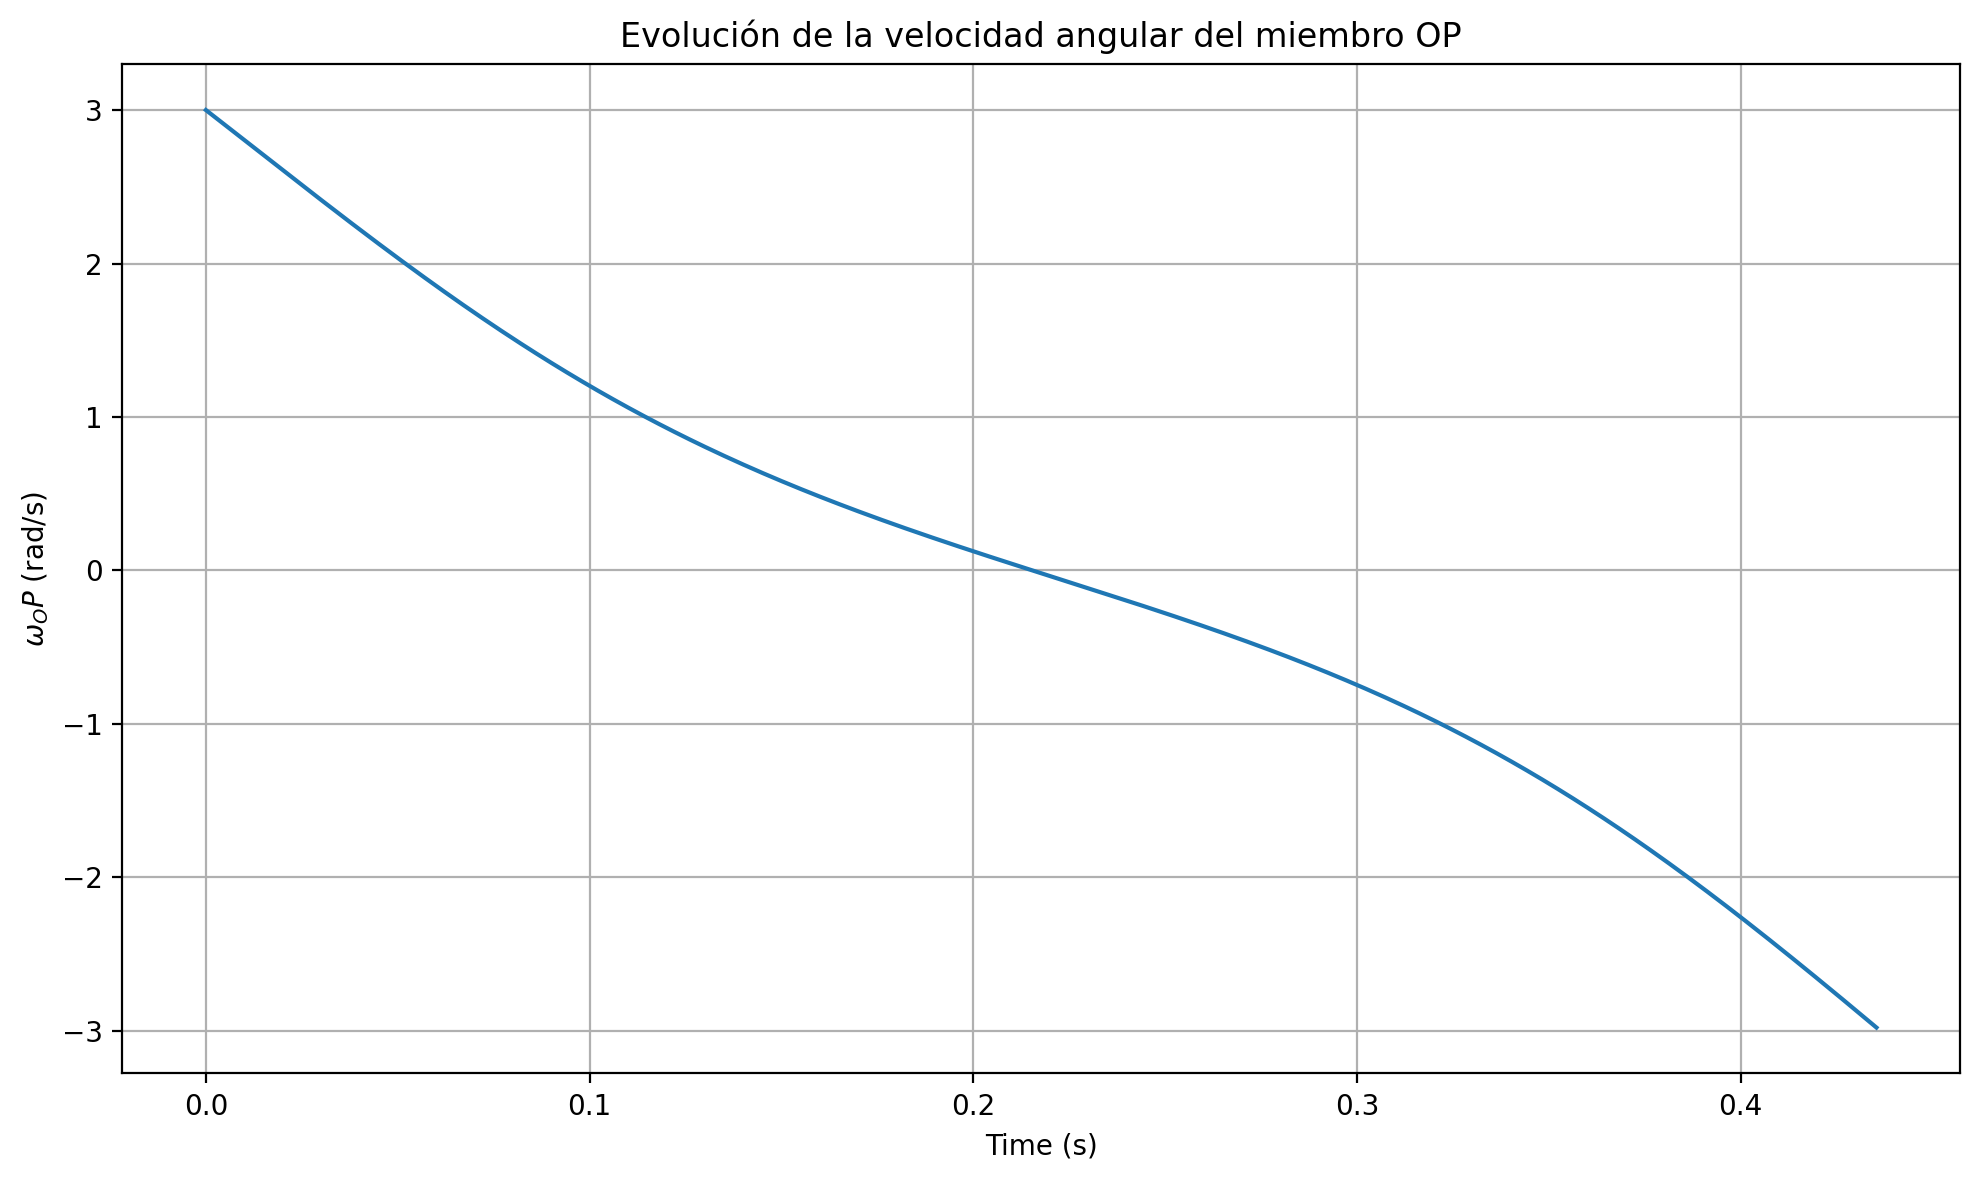

In [ ]:

eqA_params = eq_params_subs.diff(t, N).diff(t, N)
eqK1 = eqA_params.dot(N.x)
eqK2 = eqA_params.dot(N.y)

unknowns_14 = [
    FOAx, FOAy, FABx, FABy, FBCx, FBCy, FDCx, FDCy, FDOy, MOD,
    theta1.diff(t, t), theta2.diff(t, t), theta3.diff(t, t), x.diff(t, t)
]

eq14 = [eq.subs({Fin: 0}) for eq in (list(eqlist) + [eqK1, eqK2])]
FF14, bf14 = sympy.linear_eq_to_matrix(eq14, unknowns_14)

Min_const = float(M_prom)
subs_inputs = params | {Min: Min_const}

FF14_fun = sympy.lambdify(
    (theta1, theta2, theta3, x,
     theta1.diff(t), theta2.diff(t), theta3.diff(t), x.diff(t)),
    FF14.subs(subs_inputs),
    'numpy'
)

bf14_fun = sympy.lambdify(
    (theta1, theta2, theta3, x,
     theta1.diff(t), theta2.diff(t), theta3.diff(t), x.diff(t)),
    bf14.subs(subs_inputs),
    'numpy'
)

z0_box = [[np.deg2rad(45), np.deg2rad(90)]]

theta1_min = np.deg2rad(50)
theta1_max = np.deg2rad(75)

def Funcion_ode(t_num, y):
    th1, w1, x_val, xdot_val = y
    z0 = z0_box[0]

    z, _ = FK([th1, x_val], z0)
    th2, th3 = float(z[0]), float(z[1])

    var = [th1, th2, th3, x_val]
    vardot_guess = [w1, None, None, xdot_val]

    VVnum = np.array(calculateVelocityMatrix(*var), dtype=float)
    bnum_v = np.array(calculate_bias_vector(*(vardot_guess + var)), dtype=float).flatten()
    zdot = (np.linalg.pinv(VVnum) @ bnum_v).flatten()
    th2dot, th3dot = float(zdot[0]), float(zdot[1])

    A = np.array(FF14_fun(th1, th2, th3, x_val, w1, th2dot, th3dot, xdot_val), dtype=float)
    b = np.array(bf14_fun(th1, th2, th3, x_val, w1, th2dot, th3dot, xdot_val), dtype=float).flatten()

    condA = np.linalg.cond(A)
    if (not np.isfinite(condA)) or condA > 1e10:
        sol = (np.linalg.pinv(A) @ b).flatten()
    else:
        sol = np.linalg.solve(A, b)

    th1dd = float(sol[10])
    xdd = float(sol[13])

    z0_box[0] = [th2, th3]

    return [w1, th1dd, xdot_val, xdd]

#events from documentaion 

def event_theta_max(t_num, y):
    return y[0] - theta1_max
event_theta_max.terminal = True
event_theta_max.direction = 1

def event_theta_min(t_num, y):
    return y[0] - theta1_min
event_theta_min.terminal = True
event_theta_min.direction = -1

def event_omega_blowup(t_num, y):
    return 50.0 - abs(y[1])
event_omega_blowup.terminal = True
event_omega_blowup.direction = -1

def event_x_bounds(t_num, y):
    xv = y[2]
    return min(xv - 0.5, 0.9 - xv)
event_x_bounds.terminal = True
event_x_bounds.direction = -1

y0 = [np.deg2rad(50), 3.0, 0.70, 0.0]
t_span = (0.0, 1.0)
t_eval = np.linspace(t_span[0], t_span[1], 1000)

sol = solve_ivp(
    Funcion_ode,
    t_span,
    y0,
    t_eval=t_eval,
    method="RK45",
    max_step=1e-3,
    rtol=1e-6,
    atol=1e-8,
    events=[event_theta_max, event_theta_min, event_omega_blowup, event_x_bounds]
)

plt.figure(figsize=(10, 6), dpi=200)
plt.plot(sol.t, sol.y[1])
plt.xlabel('Time (s)')
plt.ylabel(f'$\omega_{OP}$ (rad/s)')
plt.title('Evolución de la velocidad angular del miembro OP')
plt.grid(True)
plt.tight_layout()
plt.show()
